# Roll-Aware Visibility with Star Tracker Earth Limb Keep-Outs

This notebook demonstrates the roll-aware visibility feature in `shortschedule`.

### Background
Pandora's **boresight** visibility constraints (Sun, Moon, Earth limb) are independent of
spacecraft roll angle.  However, the two **star trackers** are fixed in the body frame at
offsets from the boresight, so their Earth-limb keep-out constraints *do* depend on roll.

Previously the scheduler computed visibility without considering roll, then assigned roll
afterward — which could produce schedules where sequences were marked *visible* at a roll
that actually violated a star tracker keep-out.

The new approach:
1. **Sweeps** candidate roll angles from 0° to 360° in configurable steps.
2. **Filters** candidates that fail a minimum solar-panel power fraction.
3. **Evaluates** `get_visibility(…, roll=…)` at each surviving candidate.
4. **Selects** the roll that maximises visible minutes, with a tie-breaker
   favouring the sun-derived roll.

In [7]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u
from astropy.time import Time

from shortschedule import (
    ScheduleProcessor,
    XMLWriter,
    parse_science_calendar,
)
from shortschedule.roll import (
    calculate_roll,
    compute_solar_power_fraction,
    compute_mean_solar_power,
    find_best_roll_for_target,
    find_best_rolls_for_visit,
)
from shortschedule.visualizer import ScheduleVisualizer

## 1. Solar Power Fraction vs. Roll Angle

Before sweeping visibility, each candidate roll must pass a **minimum solar-panel
power threshold**.  The power fraction is computed from Lambert's cosine law applied
to the angle between the Sun direction and the solar-panel normal (the spacecraft
+Y axis).

Let's visualise how power varies with roll for a particular target and time.

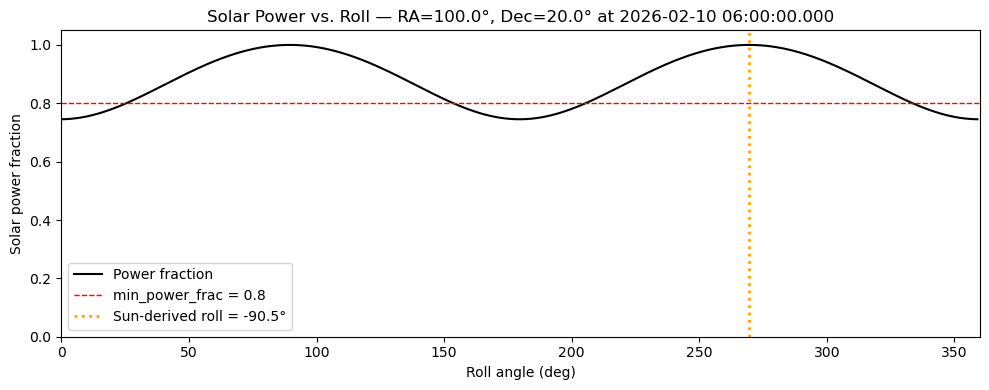

In [8]:
# Pick a target and observation time
ra, dec = 100.0, 20.0  # degrees
obs_time = Time("2026-02-10T06:00:00Z")

# Compute solar power fraction across all roll angles
rolls = np.arange(0, 360, 1.0)
power = [compute_solar_power_fraction(ra, dec, r, obs_time) for r in rolls]

# Sun-derived roll (the "default" roll from the existing algorithm)
sun_roll = calculate_roll(ra, dec, obs_time)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rolls, power, "k-", lw=1.5, label="Power fraction")
ax.axhline(0.8, color="red", ls="--", lw=1, label="min_power_frac = 0.8")
ax.axvline(
    (sun_roll + 360) % 360,
    color="orange",
    ls=":",
    lw=2,
    label=f"Sun-derived roll = {sun_roll:.1f}°",
)
ax.set_xlabel("Roll angle (deg)")
ax.set_ylabel("Solar power fraction")
ax.set_title(f"Solar Power vs. Roll — RA={ra}°, Dec={dec}° at {obs_time.iso}")
ax.set_xlim(0, 360)
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

Rolls in the valley (power < 0.8) are rejected before the visibility sweep even begins.
This avoids wasting time evaluating rolls that would starve the spacecraft of power.

## 2. Roll Sweep for a Single Target

The function `find_best_roll_for_target` takes a `Visibility` instance, target
coordinates, and a time array.  It sweeps rolls (default 2° steps), filters by
power, and keeps the roll with the most visible minutes.

We'll use the real `pandoravisibility.Visibility` class below, which includes
star-tracker Earth-limb constraints.

In [9]:
from pandoravisibility import Visibility

# TLE for Pandora
tle1 = "1 99152U 26011B  26005.66013674 +.00000000 +00000-0 +00000-0 0   16"
tle2 = "2 99152 97.6750 17.6690 0000000 328.8990 20.9640 14.86530781000004"

vis = Visibility(
    tle1, tle2,
    st_earthlimb_min=30.0 * u.deg,
    st_sun_min=44.0 * u.deg,
    st_moon_min=12.0 * u.deg,
)

In [10]:
from astropy.coordinates import SkyCoord

# Build a minute-resolution time grid for a ~2-hour window
t0 = Time("2026-02-10T06:00:00Z")
times = t0 + np.arange(120) * u.min

ra_tgt, dec_tgt = 100.0, 20.0
coord = SkyCoord(ra=ra_tgt, dec=dec_tgt, unit="deg", frame="icrs")

# --- Visibility WITHOUT roll (old behaviour) ---
vis_no_roll = vis.get_visibility(coord, times)
print(f"Visible minutes (no roll specified): {np.sum(vis_no_roll)}")

# --- Visibility at the sun-derived roll ---
sun_roll = calculate_roll(ra_tgt, dec_tgt, t0)
vis_sun_roll = vis.get_visibility(coord, times, roll=sun_roll * u.deg)
print(f"Visible minutes (sun roll {sun_roll:.1f}°):  {np.sum(vis_sun_roll)}")

# --- Best roll from sweep ---
best = find_best_roll_for_target(
    vis, ra_tgt, dec_tgt, times,
    roll_step=2.0,
    min_power_frac=0.8,
    sun_roll=sun_roll,
)
if best is not None:
    vis_best = vis.get_visibility(coord, times, roll=best * u.deg)
    print(f"Visible minutes (swept roll {best:.1f}°): {np.sum(vis_best)}")
else:
    print("No valid roll found for this target/time window")

Visible minutes (no roll specified): 37
Visible minutes (sun roll -90.5°):  37
Visible minutes (swept roll 72.0°): 66


## 3. Visibility vs. Roll Heatmap

To understand *why* certain rolls lose visibility, let's evaluate
`get_visibility(…, roll=…)` at every (time, roll) pair and plot the result.

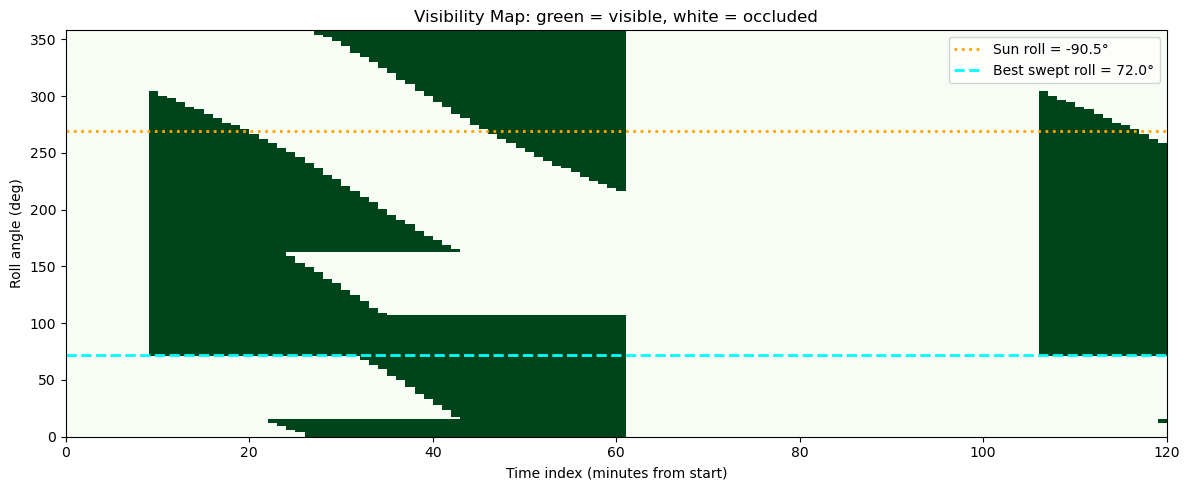

In [11]:
# Sweep rolls and build a 2-D visibility map
roll_candidates = np.arange(0, 360, 2.0)
vis_map = np.zeros((len(roll_candidates), len(times)), dtype=bool)

for i, r in enumerate(roll_candidates):
    vis_map[i] = vis.get_visibility(coord, times, roll=r * u.deg)

fig, ax = plt.subplots(figsize=(12, 5))
extent = [0, len(times), roll_candidates[0], roll_candidates[-1]]
ax.imshow(
    vis_map,
    aspect="auto",
    origin="lower",
    extent=extent,
    cmap="Greens",
    interpolation="nearest",
)
ax.axhline(
    (sun_roll + 360) % 360,
    color="orange", ls=":", lw=2,
    label=f"Sun roll = {sun_roll:.1f}°",
)
if best is not None:
    ax.axhline(
        (best + 360) % 360,
        color="cyan", ls="--", lw=2,
        label=f"Best swept roll = {best:.1f}°",
    )
ax.set_xlabel("Time index (minutes from start)")
ax.set_ylabel("Roll angle (deg)")
ax.set_title("Visibility Map: green = visible, white = occluded")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

The white horizontal bands show rolls where star-tracker Earth-limb constraints
block visibility during part of each orbit.  The sweep picks the roll with the
most green (visible) minutes.

## 4. Full Pipeline: Processing a Calendar with Roll-Aware Visibility

The `ScheduleProcessor` now accepts `roll_step` and `min_power_frac` parameters.
When star-tracker keep-out angles are set, the roll sweep runs automatically
during `process_calendar()`.

In [12]:
# Load the example long-term science calendar
xml_file = "../src/shortschedule/data/Pandora_science_calendar_20251018_tsb-futz.xml"
original_calendar = parse_science_calendar(xml_file, verbose=True)

Parsing XML file: ../src/shortschedule/data/Pandora_science_calendar_20251018_tsb-futz.xml
Root tag: {/pandora/calendar/}ScienceCalendar
Calendar valid from 2026-02-05 00:00:00 to 2027-02-04 09:47:00
Found 10 visits
Successfully parsed 10 visits with 313 total sequences


In [13]:
# --- Scheduler WITHOUT roll awareness (old behaviour) ---
# Setting all st_* params to None disables the star-tracker constraints
# and therefore the roll sweep (since get_visibility ignores roll).

scheduler_no_st = ScheduleProcessor(
    tle1, tle2,
    st_earthlimb_min=None,
    st_sun_min=None,
    st_moon_min=None,
)

window_start = Time("2026-02-05T00:00:00Z")
window_days = 3

cal_no_st = scheduler_no_st.process_calendar(
    original_calendar,
    window_start=window_start,
    window_duration_days=window_days,
)
print("=== Without Star-Tracker Constraints ===")
scheduler_no_st.print_timing_summary(cal_no_st)
scheduler_no_st.print_gap_summary()

WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
TOI-674 b: 2026-02-05T00:28:00.000, 2026-02-05T00:22:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
GJ_3470: 2026-02-05T00:54:00.000, 2026-02-05T00:54:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
TOI-674 b: 2026-02-05T02:05:00.000, 2026-02-05T01:59:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
GJ_3470: 2026-02-05T02:31:00.000, 2026-02-05T02:31:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
TOI-674 b: 2026-02-05T03:42:00.000, 2026-02-05T03:36:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
GJ_3470: 2026-02-05T04:08:00.000, 2026-02-05T04:08:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
TOI-674 b: 2026-02-05T05:19:00.000, 2026-02-05T05:13:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
GJ_3470: 2026-02-05T05:45:00.000, 2026-02-05T05:45:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
TOI-674 b: 2026-02-05T06:56:00.000, 2026-02-05T06:50:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
GJ_3470: 2026-02-0

In [15]:
# --- Scheduler WITH roll-aware star-tracker keep-outs ---
scheduler_st = ScheduleProcessor(
    tle1, tle2,
    st_earthlimb_min=30.0,
    st_sun_min=44.0,
    st_moon_min=12.0,
    roll_step=2.0,
    min_power_frac=0.7,
)

cal_st = scheduler_st.process_calendar(
    original_calendar,
    window_start=window_start,
    window_duration_days=window_days,
)
print("=== With Star-Tracker Constraints ===")
scheduler_st.print_timing_summary(cal_st)
scheduler_st.print_gap_summary()

WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
TOI-674 b: 2026-02-05T00:28:00.000, 2026-02-05T00:22:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
GJ_3470: 2026-02-05T00:54:00.000, 2026-02-05T00:54:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
HAT-P-12: 2026-02-05T01:15:00.000, 2026-02-05T01:07:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
TOI-674 b: 2026-02-05T02:05:00.000, 2026-02-05T01:59:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
GJ_3470: 2026-02-05T02:31:00.000, 2026-02-05T02:31:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
HAT-P-12: 2026-02-05T02:52:00.000, 2026-02-05T02:44:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
TOI-674 b: 2026-02-05T03:42:00.000, 2026-02-05T03:36:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
GJ_3470: 2026-02-05T04:08:00.000, 2026-02-05T04:08:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
HAT-P-12: 2026-02-05T04:29:00.000, 2026-02-05T04:21:00.000
WARNING MINIMUM SEQUENCE DURATION ISSUE WITH
TOI-674 b: 2026-02-

## 5. Compare Scheduled Observation Time

Let's compare summary statistics between the two runs to see the impact of
star-tracker constraints.

In [ ]:
stats_no_st = cal_no_st.get_summary_stats()
stats_st = cal_st.get_summary_stats()

print(f"{'Metric':<40} {'No ST':>10} {'With ST':>10}")
print("-" * 62)
for key in stats_no_st:
    v1 = stats_no_st[key]
    v2 = stats_st.get(key, "--")
    if isinstance(v1, float):
        print(f"{key:<40} {v1:>10.2f} {v2:>10.2f}")
    else:
        print(f"{key:<40} {str(v1):>10} {str(v2):>10}")

Metric                                        No ST    With ST
--------------------------------------------------------------
total_visits                                      6          6
total_sequences                                 136        136
total_duration_minutes                      4459.00    4312.00
total_duration_hours                          74.32      71.87
total_duration_days                            3.10       2.99
calendar_span_days                             3.01       3.01
duty_cycle_percent                           102.86      99.47
start_date                               2026-02-05T00:00:00.000 2026-02-05T00:00:00.000
end_date                                 2026-02-08T00:15:00.000 2026-02-08T00:15:00.000
priority_breakdown                       {'priority_1': {'count': 28, 'duration_hours': np.float64(21.666666666666664), 'duration_days': np.float64(0.9027777777777776)}, 'priority_0': {'count': 105, 'duration_hours': np.float64(50.11666666666666), 'durati

## 6. Inspect Precomputed Target Rolls

The scheduler stores the swept rolls it found in
`scheduler._computed_target_rolls`.  This is a nested dict:

```
{visit_id: {target_name: roll_deg_or_None}}
```

In [ ]:
# Show the precomputed rolls from the star-tracker-aware run
for visit_id, target_rolls in scheduler_st._computed_target_rolls.items():
    print(f"Visit {visit_id}:")
    for target, roll in target_rolls.items():
        if roll is not None:
            print(f"  {target:>20s}  →  roll = {roll:+7.2f}°")
        else:
            print(f"  {target:>20s}  →  no valid roll found")

Visit 0001:
             TOI-674 b  →  roll = -148.00°
               GJ_3470  →  roll =  -24.00°
              HAT-P-12  →  roll =  -88.00°
Visit 0002:
         TYC 822-718-1  →  no valid roll found
Visit 0003:
               GJ_3470  →  no valid roll found
                K2-275  →  no valid roll found
               TOI-674  →  roll = -148.00°
              HAT-P-12  →  roll =  +98.00°
Visit 0004:
              HD_73583  →  roll =  -64.00°
             GJ_3470 b  →  roll =  -18.00°
              TOI-1801  →  roll = -160.00°
              TOI-3884  →  roll =  -80.00°
                  K2-3  →  roll =  -46.00°
              HAT-P-12  →  roll =  -88.00°
Visit 0005:
                  K2-3  →  roll =  -44.00°
              HD_73583  →  roll =  +52.00°
                K2-275  →  no valid roll found
               GJ_3470  →  no valid roll found
              HAT-P-12  →  roll = +106.00°
Visit 0006:
               TOI-674  →  roll = -156.00°
               GJ_3470  →  roll =  -16.00°
     

## 7. Validation

Run the built-in validators.  With roll-aware scheduling, `validate_visibility`
re-checks each sequence using the **precomputed roll** — so visibility issues
should be zero (or minimal).

In [ ]:
vis_issues = scheduler_st.validate_visibility(cal_st)
print(f"Visibility issues: {len(vis_issues)}")
for issue in vis_issues[:5]:
    print(" ", issue)

overlap_issues = scheduler_st.validate_no_overlaps_astropy(cal_st)
print(f"\nOverlap issues:   {len(overlap_issues)}")

exp_issues = scheduler_st.validate_payload_exposures(cal_st, report_issues=True)
print(f"Exposure issues:  {len(exp_issues)}")

Visibility issue: TOI-674 b 2026-02-05T00:00:00.000 2026-02-05T00:22:00.000 001
Visibility issue: GJ_3470 2026-02-05T00:22:00.000 2026-02-05T00:54:00.000 002
Visibility issue: HAT-P-12 2026-02-05T00:54:00.000 2026-02-05T01:07:00.000 003
Visibility issue: TOI-674 b 2026-02-05T01:07:00.000 2026-02-05T01:59:00.000 004
Visibility issue: GJ_3470 2026-02-05T01:59:00.000 2026-02-05T02:31:00.000 005
Visibility issue: HAT-P-12 2026-02-05T02:31:00.000 2026-02-05T02:44:00.000 006
Visibility issue: TOI-674 b 2026-02-05T02:44:00.000 2026-02-05T03:36:00.000 007
Visibility issue: GJ_3470 2026-02-05T03:36:00.000 2026-02-05T04:08:00.000 008
Visibility issue: HAT-P-12 2026-02-05T04:08:00.000 2026-02-05T04:21:00.000 009
Visibility issue: TOI-674 b 2026-02-05T04:21:00.000 2026-02-05T05:13:00.000 010
Visibility issue: GJ_3470 2026-02-05T05:13:00.000 2026-02-05T05:45:00.000 011
Visibility issue: HAT-P-12 2026-02-05T05:45:00.000 2026-02-05T05:58:00.000 012
Visibility issue: TOI-674 b 2026-02-05T05:58:00.000 

## 8. Visualise the Processed Calendar

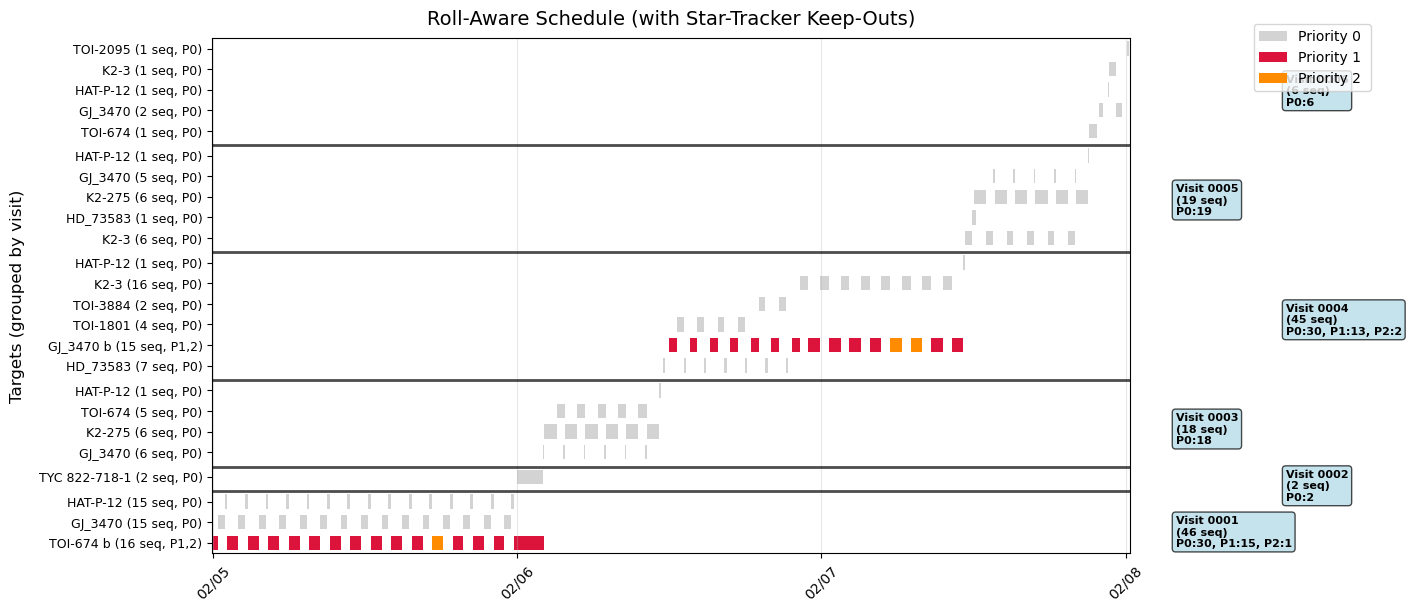

In [ ]:
visualizer = ScheduleVisualizer(scheduler_st)
fig = visualizer.plot_gantt_timeline_by_priority(
    cal_st,
    figsize=(14, 6),
    show_sequence_labels=False,
    title="Roll-Aware Schedule (with Star-Tracker Keep-Outs)",
)

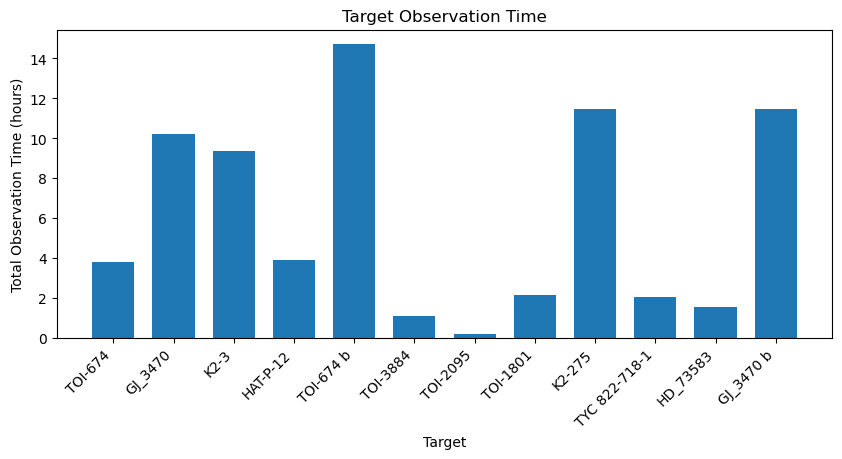

In [ ]:
fig, ax = visualizer.plot_target_time(cal_st)

## 9. Effect of `min_power_frac` Threshold

Raising `min_power_frac` narrows the set of acceptable rolls.  If the threshold
is too high, some targets may have *no* valid roll, reducing scheduled time.

In [ ]:
# Compare visible minutes at different min_power_frac thresholds
# for a single target using the roll sweep.

t0 = Time("2026-02-10T06:00:00Z")
sweep_times = t0 + np.arange(120) * u.min
ra_demo, dec_demo = 100.0, 20.0
sun_roll_demo = calculate_roll(ra_demo, dec_demo, t0)

thresholds = [0.0, 0.4, 0.6, 0.8, 0.9, 0.95, 1.0]
print(f"{'min_power_frac':>16}  {'Best roll (°)':>14}  {'Visible min':>12}")
print("-" * 48)

for thresh in thresholds:
    best_r = find_best_roll_for_target(
        vis, ra_demo, dec_demo, sweep_times,
        roll_step=2.0,
        min_power_frac=thresh,
        sun_roll=sun_roll_demo,
    )
    if best_r is not None:
        coord_demo = SkyCoord(ra=ra_demo, dec=dec_demo, unit="deg", frame="icrs")
        n_vis = np.sum(vis.get_visibility(coord_demo, sweep_times, roll=best_r * u.deg))
        print(f"{thresh:>16.2f}  {best_r:>+14.1f}  {n_vis:>12d}")
    else:
        print(f"{thresh:>16.2f}  {'None':>14}  {'--':>12}")

  min_power_frac   Best roll (°)   Visible min
------------------------------------------------
            0.00           +72.0            66
            0.40           +72.0            66
            0.60           +72.0            66
            0.80           +72.0            66
            0.90           +72.0            66
            0.95           +72.0            66
            1.00            None            --


## 10. Write Output Calendar

The processed calendar (with roll-aware visibility) can be written to XML as usual.

In [ ]:
output_path = XMLWriter().write_calendar(cal_st)
print(f"Written to: {output_path}")

Written to: PAN-SCICAL-TST-20260302-VF-20260205-EX-20260208-R001.xml
